In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("HousePricePrediction.csv")
data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [3]:
df = data.dropna()
df

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,7917,Inside,1Fam,5,1999,2000,VinylSd,0.0,953.0,175000.0
1456,1456,20,RL,13175,Inside,1Fam,6,1978,1988,Plywood,163.0,1542.0,210000.0
1457,1457,70,RL,9042,Inside,1Fam,9,1941,2006,CemntBd,0.0,1152.0,266500.0
1458,1458,20,RL,9717,Inside,1Fam,6,1950,1996,MetalSd,1029.0,1078.0,142125.0


In [4]:
df['LotConfig'].unique()

array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object)

<Axes: xlabel='YearBuilt', ylabel='YearRemodAdd'>

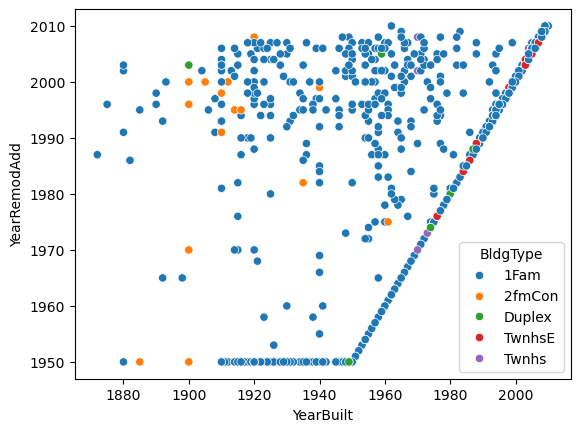

In [5]:
sns.scatterplot(x =df['YearBuilt'],y =df['YearRemodAdd'] , hue = df['BldgType'])

In [6]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]
col = ['MSZoning','LotConfig','BldgType','Exterior1st']
X = pd.get_dummies(X, columns=col,dtype=int)

In [7]:
X.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [8]:
# Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
X_test.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
892,892,20,8414,8,1963,2003,0.0,1059.0,0,0,...,0,1,0,0,0,0,0,0,0,0
1105,1105,60,12256,5,1994,1995,0.0,1463.0,0,0,...,0,1,0,0,0,0,0,0,0,0
413,413,30,8960,6,1927,1950,0.0,1008.0,0,0,...,0,0,0,0,0,0,0,0,0,1
522,522,50,5000,7,1947,1950,0.0,1004.0,0,0,...,1,0,0,0,0,0,0,0,0,0
1036,1036,20,12898,5,2007,2008,0.0,1620.0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [10]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Predict values
y_pred = model.predict(X_test)

In [12]:
y_pred

array([168733.00189047, 243223.76121096, 114785.41227824, 157880.21908263,
       254517.60086044, 156703.57888502, 178379.5616667 , 127064.11121215,
       133197.41885953, 149331.19082238, 131000.75218361, 122815.20502716,
        79738.39227946, 239339.94776738, 218129.44955193, 177551.14202489,
       218101.29975087, 178803.12616049, 135322.80805365, 233339.70771398,
       163212.59495861, 219590.49747877, 202612.80166678, 154541.46480402,
       224316.14395911, 167384.05651947, 228422.20457253, 110932.01963279,
       215243.13926237, 205067.00490287, 115672.6606187 , 231708.53736395,
       224244.00470912, 129036.96376608, 251253.52486043, 140922.92968156,
       170428.1779862 , 217706.51759571, 254810.7443039 ,  78172.67334391,
       119177.72918108, 218351.79277334, 125276.92523562, 291207.78191567,
       141515.5765355 , 104779.22150902, 127608.97846477, 131336.69938206,
       320741.92793959, 146047.68650297, 111720.0489456 , 193398.07005709,
       123511.08279435, 2

In [13]:
# Evaluate 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.6196387511450039
adjusted r^2: 0.5625093936094708
